<a href="https://colab.research.google.com/github/miaalvaradoc/IA-TEAM-ASSIGNMENTS/blob/main/ASSIGNMENTS/AF2_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part 1: Data Loading and Exploration**

First, we import the libraries we're going to need in this assignment.

In [108]:
#Libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.linear_model
#import sys

Then we load the diabetes dataset from a specified URL and then displays the first 10 rows to provide a quick overview of the data.

In [109]:
#Load data
DIABETES_data = pd.read_csv("https://raw.githubusercontent.com/miaalvaradoc/CSV-FILES/refs/heads/main/diabetes.csv", thousands=',')
DIABETES_data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


Here we print a summary of the DataFrame, including the data types of each column, the number of non-null values, and memory usage. This helps in understanding the structure and completeness of the data.

In [110]:
print(DIABETES_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


This cell prints the dimensions (number of rows and columns) of the `DIABETES_data` DataFrame. *(This was just for fun)*

In [111]:
print(DIABETES_data.shape)

(768, 9)


Here we can check for missing values in each column of the DataFrame and sums them up, indicating how many missing values are present per column. *(We had no missing values)*

In [112]:
print(DIABETES_data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Then we generated descriptive statistics using .describe() for each numerical column in the DataFrame, such as count, mean, standard deviation, min, max, and quartiles, providing insights into the data distribution.

In [113]:
DIABETES_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# **Part 2: Data Cleaning and Normalization**

In here we identified specific columns ***(Glucose, BloodPressure, SkinThickness, Insulin, BMI)*** where zero values are considered missing or erroneous. It then replaces these zero values with the median of their respective columns (excluding zeros for median calculation) to handle missing data.



In [114]:
columns_to_replace = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_to_replace:
    median_val = DIABETES_data[col][DIABETES_data[col] != 0].median()
    print(f"The median of column {col}: {median_val} ")
    DIABETES_data[col] = DIABETES_data[col].replace(0, median_val)

The median of column Glucose: 117.0 
The median of column BloodPressure: 72.0 
The median of column SkinThickness: 29.0 
The median of column Insulin: 125.0 
The median of column BMI: 32.3 


Then we added a display of the first few rows of the** DIABETES_data** DataFrame after the zero values in the specified columns have been replaced by their medians, allowing for a visual check of the changes.

In [115]:
print(DIABETES_data.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35      125  33.6   
1            1       85             66             29      125  26.6   
2            8      183             64             29      125  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


This cell performs Min-Max normalization on the entire **DIABETES_data** DataFrame. It scales the numerical features to a range between 0 and 1, which is often done before training machine learning models. It then prints both the original and the normalized data.

In [116]:
data = DIABETES_data

# Calculation of min and max by column
min_vals = np.min(data, axis=0)
max_vals = np.max(data, axis=0)

# Min-Max normalization
NOMDIABETES_data = (data - min_vals) / (max_vals - min_vals)

print("Original data:")
print(data)
print("Normalized data:")
print(NOMDIABETES_data)

Original data:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35      125  33.6   
1              1       85             66             29      125  26.6   
2              8      183             64             29      125  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27      125  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60             29      125  30.1   
767            1       93             70             31      125  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1   

# **Part 3: Data Visualization**

Now we skip to the part of our data visualization, where we generate two histograms to visualize the distribution of 'Glucose' levels: one before normalization and one after normalization. This helps to observe the effect of the normalization process on the data distribution.

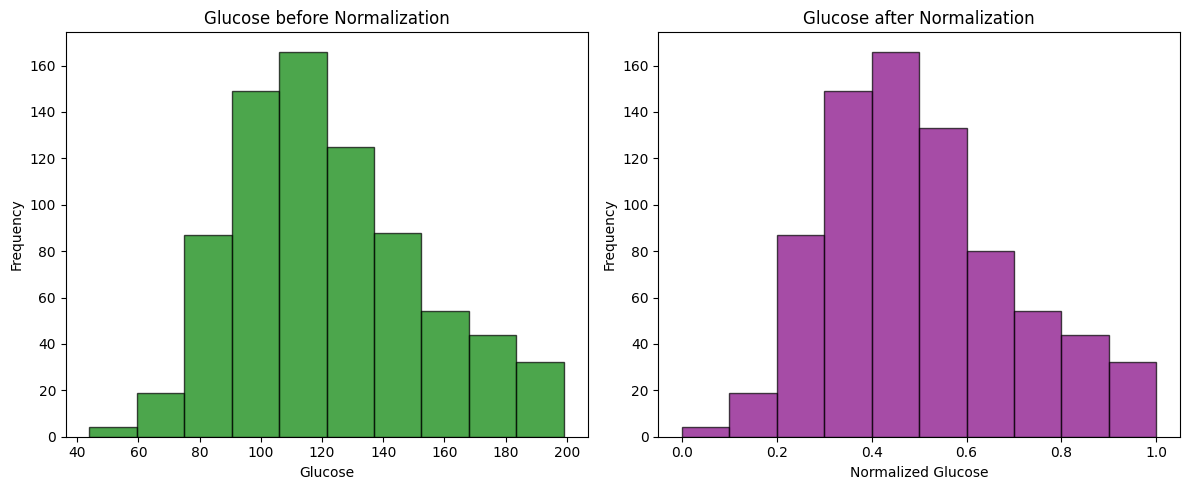

In [117]:
GLUCOSE_levels = DIABETES_data['Glucose']
NOMGLUCOSE_levels = NOMDIABETES_data['Glucose']

fig, axs = plt.subplots(1, 2, figsize=(12, 5)) # Creates a row with two plots

# Plot for Glucose before Normalization
axs[0].hist(GLUCOSE_levels, color='green', alpha=0.7, edgecolor='black')
axs[0].set_title('Glucose before Normalization')
axs[0].set_xlabel('Glucose')
axs[0].set_ylabel('Frequency')

# Plot for Glucose after Normalization
axs[1].hist(NOMGLUCOSE_levels, color='purple', alpha=0.7, edgecolor='black')
axs[1].set_title('Glucose after Normalization')
axs[1].set_xlabel('Normalized Glucose')
axs[1].set_ylabel('Frequency')

plt.tight_layout()  # Adjusts the spacing to prevent labels from overlapping
plt.show()  # Shows the graphs/plots

Now we add a fuction to create a boxplot for the **BloodPressure** column to identify potential outliers and visualize the spread and central tendency of the data.

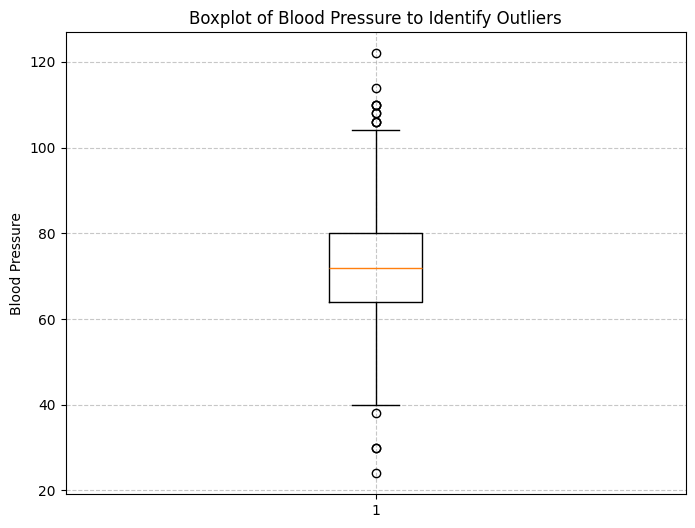

In [118]:
plt.figure(figsize=(8, 6))
plt.boxplot(DIABETES_data['BloodPressure'])
plt.title('Boxplot of Blood Pressure to Identify Outliers')
plt.ylabel('Blood Pressure')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Here we generate a scatter plot comparing 'Glucose' levels against 'BMI'. This visualization helps to explore the relationship and potential correlation between these two variables.

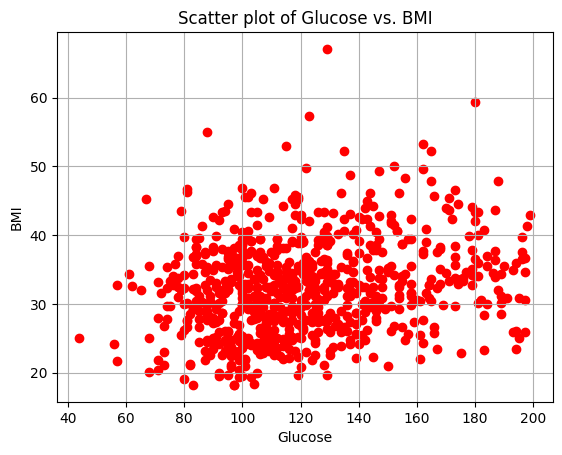

In [119]:
BMI= DIABETES_data['BMI']


plt.scatter(GLUCOSE_levels, BMI, color='red')  # Draws the scatter plot
plt.title("Scatter plot of Glucose vs. BMI")  # Title
plt.xlabel("Glucose")  # Label for the x-axis
plt.ylabel("BMI")  # Label for the y-axis
plt.grid(True)  # Shows the grid
plt.show()  # Shows the graph

Last but not least, this cell creates a bar chart showing the count of patients with and without diabetes (based on the **Outcome column**).

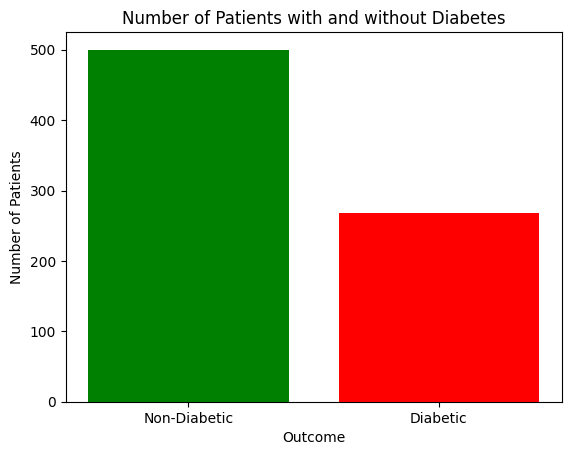

In [120]:
outcome_counts = DIABETES_data['Outcome'].value_counts()
categorias = outcome_counts.index.map(lambda x: 'Diabetic' if x == 1 else 'Non-Diabetic')
valores = outcome_counts.values

plt.bar(categorias, valores, color=['green', 'red'])  # Draws the bar chart/graph
plt.title("Number of Patients with and without Diabetes")  # Title
plt.xlabel("Outcome")  # Label for the x-axis
plt.ylabel("Number of Patients")  # Label for the y-axis
plt.show()  # Shows the graph/chart